In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# Read the file.

In [2]:
ls

 Volume in drive C has no label.
 Volume Serial Number is 80D1-CA4D

 Directory of C:\Users\ADMIN\Documents\dat\Mi\ML 02 to 04\LR\Simple Linear Regression

23-04-2026  14:39    <DIR>          .
23-04-2026  14:39    <DIR>          ..
22-04-2026  15:34    <DIR>          .ipynb_checkpoints
09-04-2026  11:09             1,386 scores.csv
23-04-2026  14:39            56,460 Simple Linear Regression.ipynb
               2 File(s)         57,846 bytes
               3 Dir(s)  102,273,282,048 bytes free


In [3]:
df = pd.read_csv("scores.csv")

In [4]:
df.head()

,time_study,Marks
0,4.508,19.202
1,0.096,7.734
2,3.133,13.811
3,7.909,53.018
4,7.811,55.299


## Checke the file have missing values or not.

In [5]:
df.isna()

,time_study,Marks
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
95,False,False
96,False,False
97,False,False
98,False,False


In [6]:
df.isna().sum()

time_study    0
Marks         0
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   time_study  100 non-null    float64
 1   Marks       100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


## Check for outliers and skewness.

In [8]:
df.describe()

,time_study,Marks
count,100.000000,100.000000
mean,4.077140,24.417690
std,2.372914,14.326199
min,0.096000,5.609000
25%,2.058500,12.633000
50%,4.022000,20.059500
75%,6.179250,36.676250
max,7.957000,55.299000


<Axes: xlabel='Marks', ylabel='Density'>

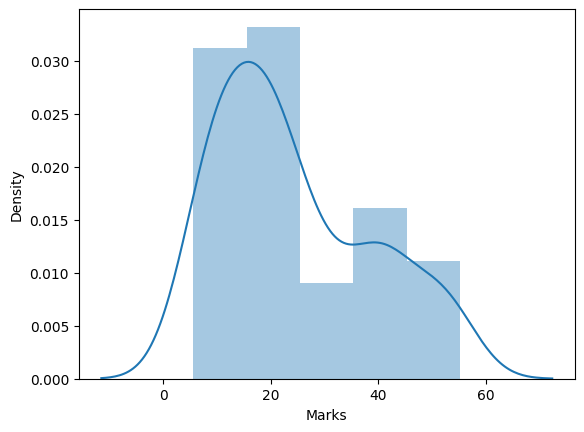

In [9]:
sns.distplot(df["Marks"])

In [10]:
def grades(marks):
    if marks > 90 :
        return "A"
    elif marks < 90 and marks > 50 :
        return "B"
    elif marks <= 50  and marks > 30 :
        return "C"
    else:
        return "D"

In [11]:
df["Grades1"] = df["Marks"].apply(grades)

In [12]:
x = [grades(m)  for  m in  df["Marks"]]
df["Grades"] = x

In [13]:
df

,time_study,Marks,Grades1,Grades
0,4.508,19.202,D,D
1,0.096,7.734,D,D
2,3.133,13.811,D,D
3,7.909,53.018,B,B
4,7.811,55.299,B,B
...,...,...,...,...
95,3.561,19.128,D,D
96,0.301,5.609,D,D
97,7.163,41.444,C,C
98,0.309,12.027,D,D


In [14]:
df.drop(["Grades"], axis=1, inplace=True)

In [15]:
# df["temp"] = [ i for i in range(100)]

##### Find the count of studet base on grades.

In [16]:
df["Grades1"].value_counts()

Grades1
D    69
C    22
B     9
Name: count, dtype: int64

<Axes: xlabel='Grades1'>

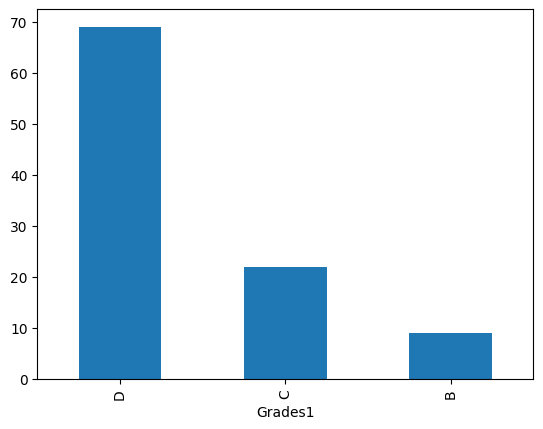

In [17]:
df["Grades1"].value_counts().plot(kind="bar")

<Axes: >

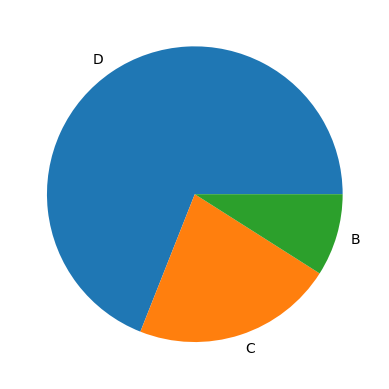

In [18]:
df["Grades1"].value_counts().plot(kind="pie")

# Find teh relation between columns.

In [19]:
cols = df.select_dtypes(["int", "float"]).columns

In [20]:
cols

Index(['time_study', 'Marks'], dtype='str')

In [21]:
df[cols].corr()

,time_study,Marks
time_study,1.000000,0.942254
Marks,0.942254,1.000000


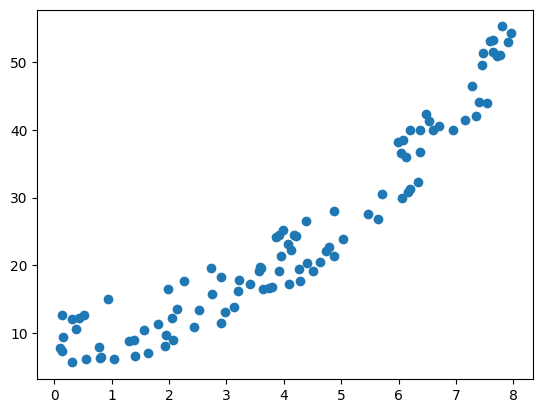

In [22]:
plt.scatter(df["time_study"], df["Marks"])

## Divide data into f and r.

In [23]:
df.columns

Index(['time_study', 'Marks', 'Grades1'], dtype='str')

In [24]:
f = df.iloc[ : , :1 ] # 2D
y = df.iloc[ : ,  1]  # 1D

### Divide data into train and test.

In [25]:
from sklearn.model_selection import train_test_split

In [28]:
xtrain, xtest, ytrain, ytest   =    train_test_split(f, y,   test_size=0.2,  random_state=1)

### Model building.

In [30]:
# import model.
from sklearn.linear_model  import LinearRegression

# make an object of a model
linreg = LinearRegression()


# train the model.
linreg.fit(xtrain, ytrain)


# make prediction.
yp = linreg.predict(xtest)

In [31]:
yp

array([29.15440672, 17.8853464 , 38.65318761, 19.62125148, 21.79829414,
       44.00985838, 12.24222265, 14.18437387, 25.71124188, 18.21763186,
        1.97001871, 37.5188338 , 22.97848043,  2.99552039, 24.52532653,
       28.34088025, 15.65101314, 30.02522379, 39.62712775, 45.76867969])

In [32]:
ytest

23    28.043
14    11.397
38    41.358
5     17.822
42    19.771
59    51.343
31     8.100
81    17.705
13    17.672
36    13.119
64    12.591
99    32.357
46    16.703
98    12.027
86    23.149
20    22.073
71    13.416
92    23.916
50    40.602
39    51.142
Name: Marks, dtype: float64

In [33]:
linreg.intercept_

np.float64(1.225240960988522)

In [34]:
linreg.coef_

array([5.72905964])

### Lets' check the line drawn bey the model.

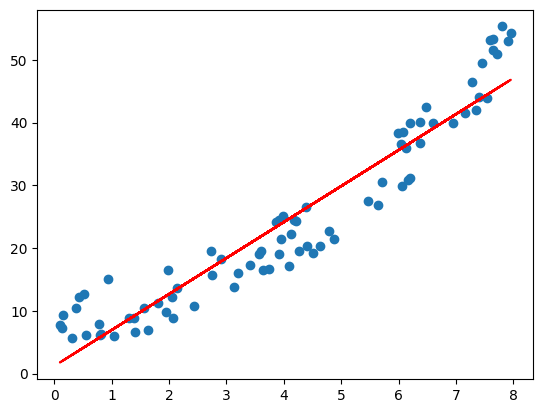

In [37]:
plt.scatter( xtrain, ytrain)
plt.plot(  xtrain,  linreg.predict(xtrain), color="red")

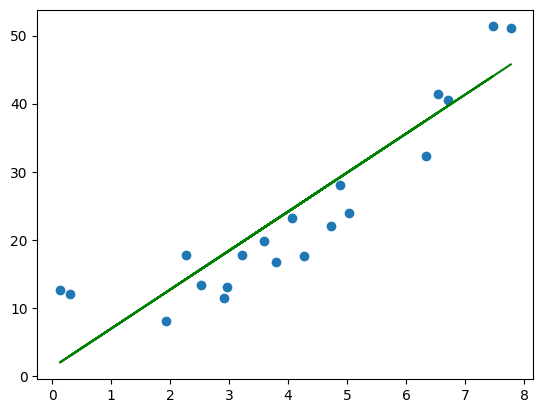

In [ ]:
plt.scatter( xtest, ytest)
plt.plot(   xtest,    yp, color="green")

# Model evaluation.

In [41]:
from sklearn.metrics import  mean_absolute_error, mean_squared_error,  root_mean_squared_error, r2_score

In [42]:
mae = mean_absolute_error(yp,  ytest)
mse = mean_squared_error(yp,   ytest)
rmse = mean_absolute_error(yp, ytest)

print(mae)
print(mse)
print(rmse)

4.7845693335570125
30.28354175040464
4.7845693335570125


In [43]:
r2 = r2_score(yp, ytest)

In [44]:
r2

0.7926954713535577

# Main target in ML.

- to make prediction form unkwon data.

In [47]:
time = int(input("Enter hoursof study "))

p = linreg.predict([[time]])
print(f"After studying of {time} number of hours your will got {p[0]} amount of marks")

Enter hoursof study  3


After studying of 3 number of hours your will got 18.412419890661788 amount of marks
